Baseline (2024): 1018.1K t
Pearson R (rain vs veg): -0.483  p=0.4094
ARIMA   φ=0.0168  RMSE=18.66K  Fore=[1017.7 1017.7 1017.7]
Holt-W  α=0.0000  β=0.0000  RMSE=10.67K  Fore=[1046.2 1052.4 1058.5]
Prophet RMSE=10.67K  Fore=[1052.4 1058.5 1064.7]

Model                    RMSE     2026     2027     2028
--------------------------------------------------------
ARIMA(1,1,0)            18.66   1017.7   1017.7   1017.7
Holt-Winters            10.67   1046.2   1052.4   1058.5
Prophet                 10.67   1052.4   1058.5   1064.7

Saved: ChartI_MultiModel_Forecast.png
Saved: ChartI_Individual_Models.png

All charts generated successfully.


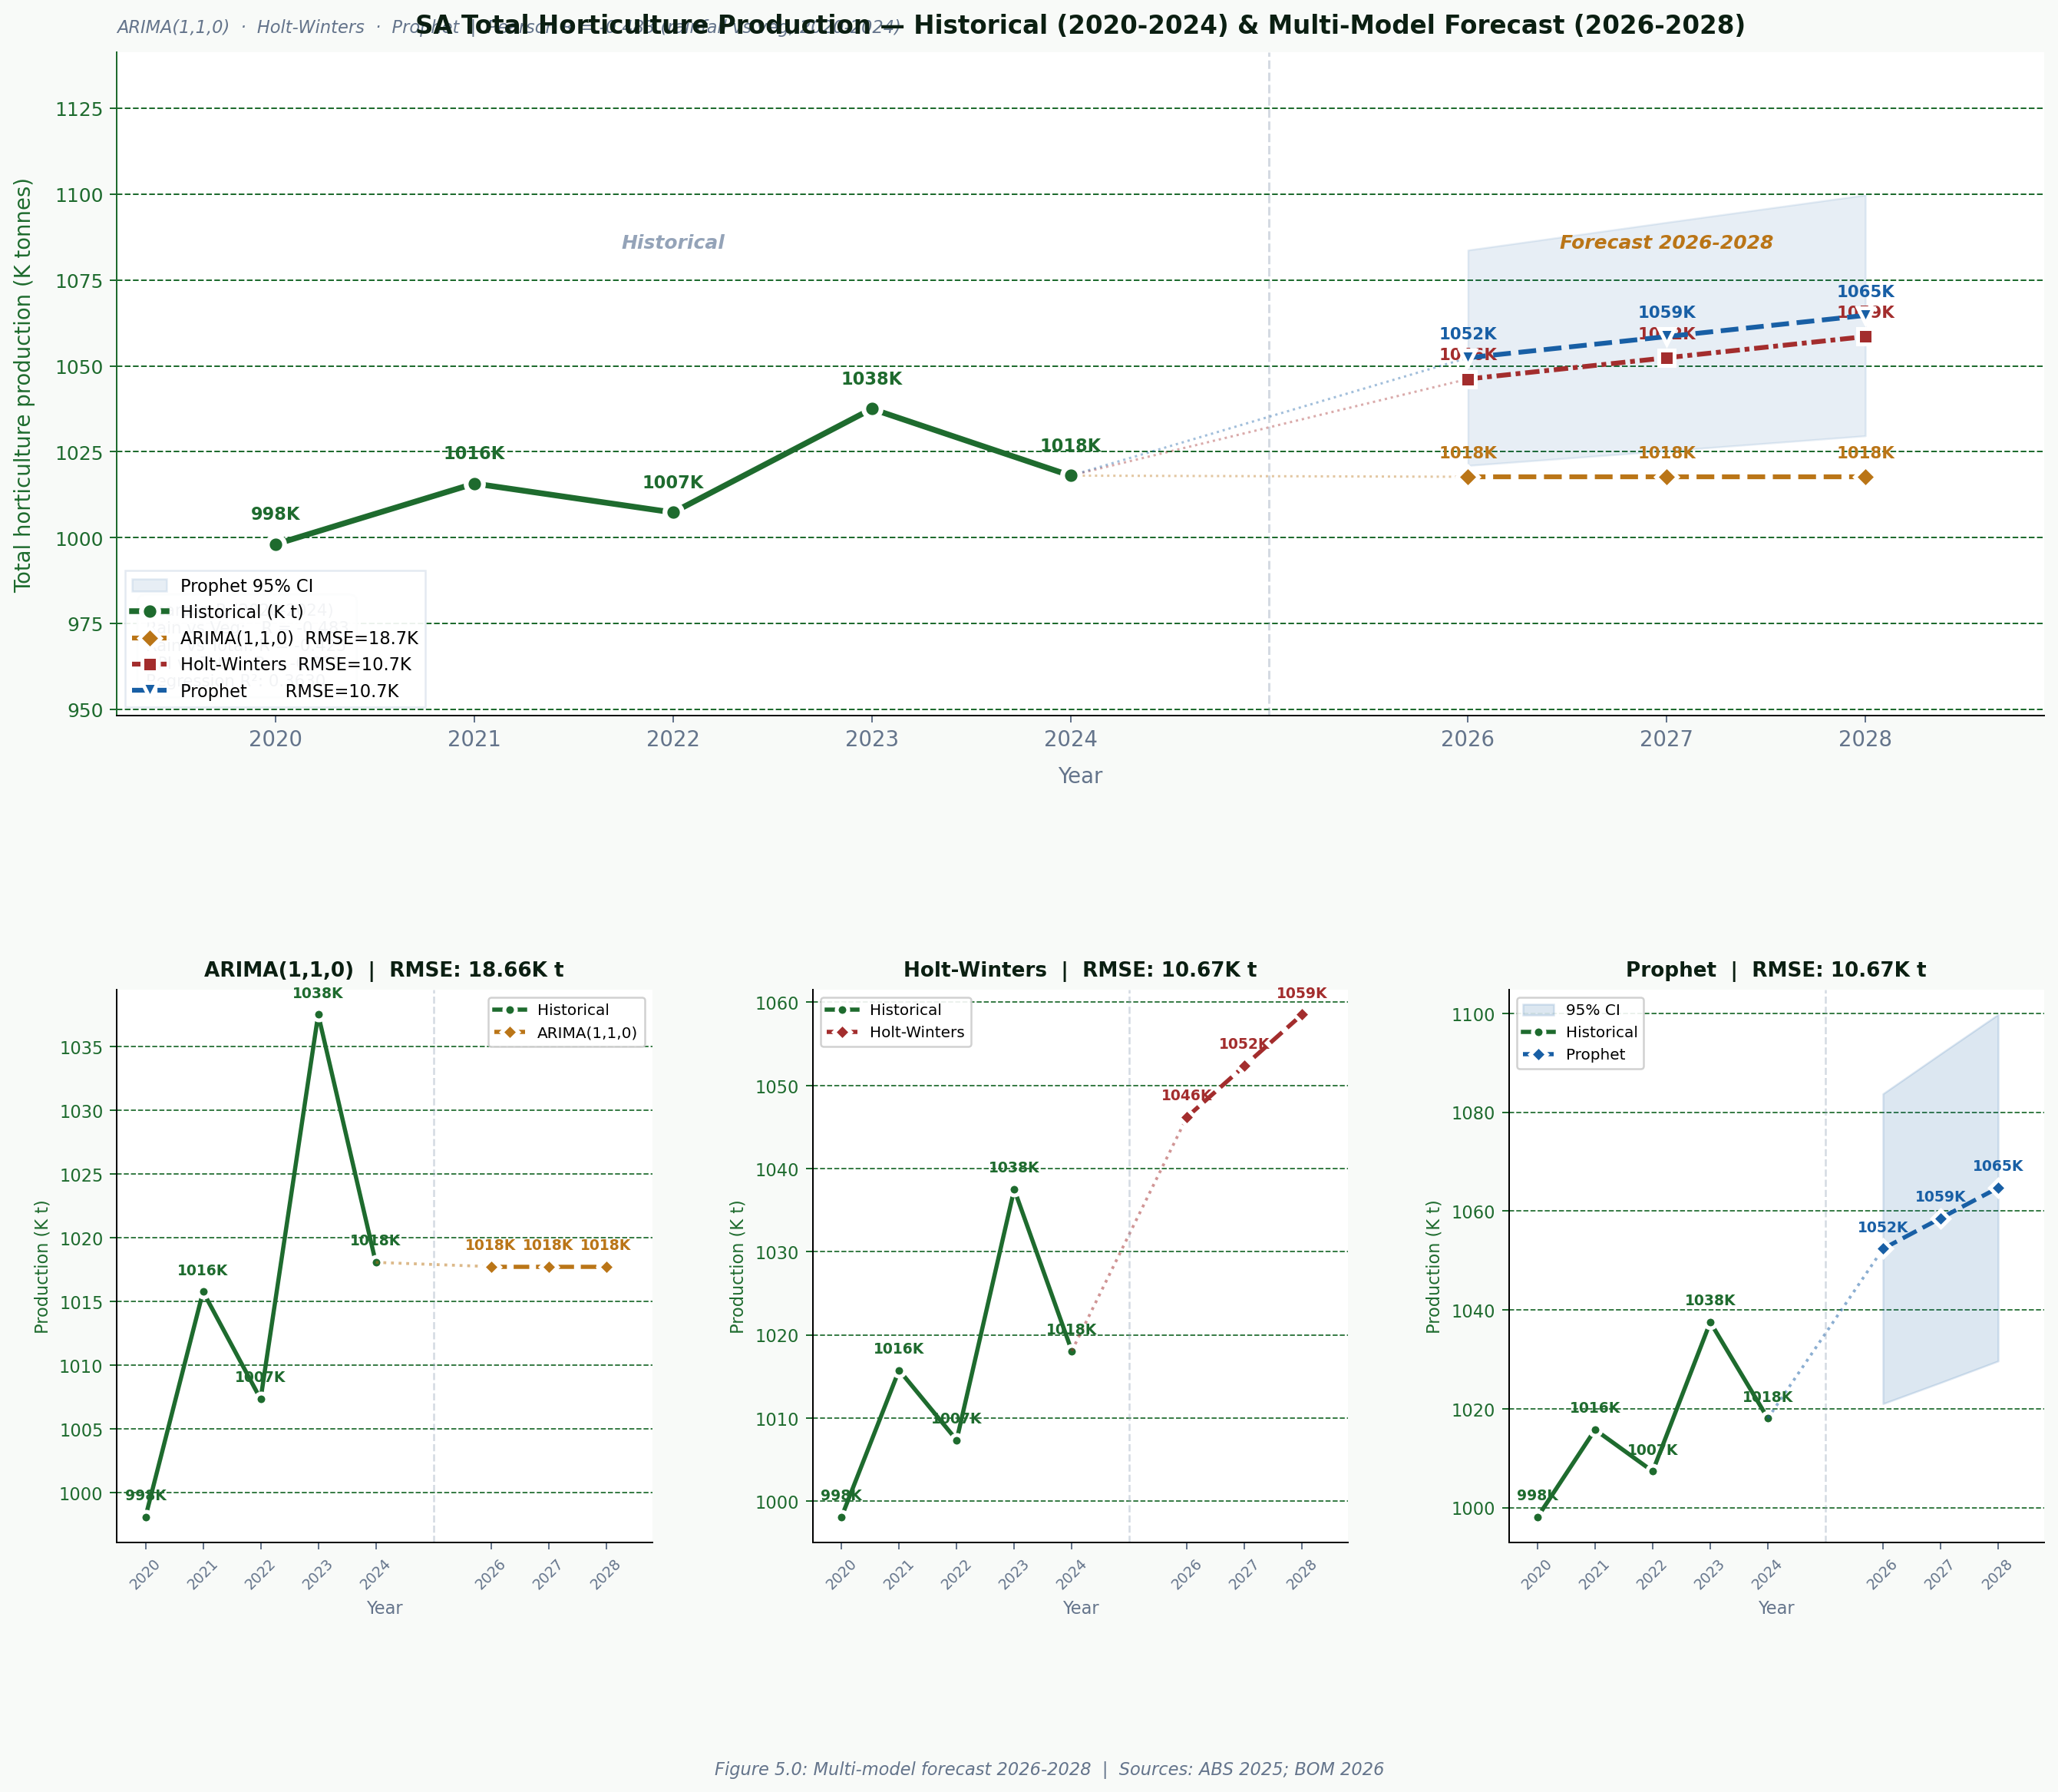

Saved: ChartI_Combined.png


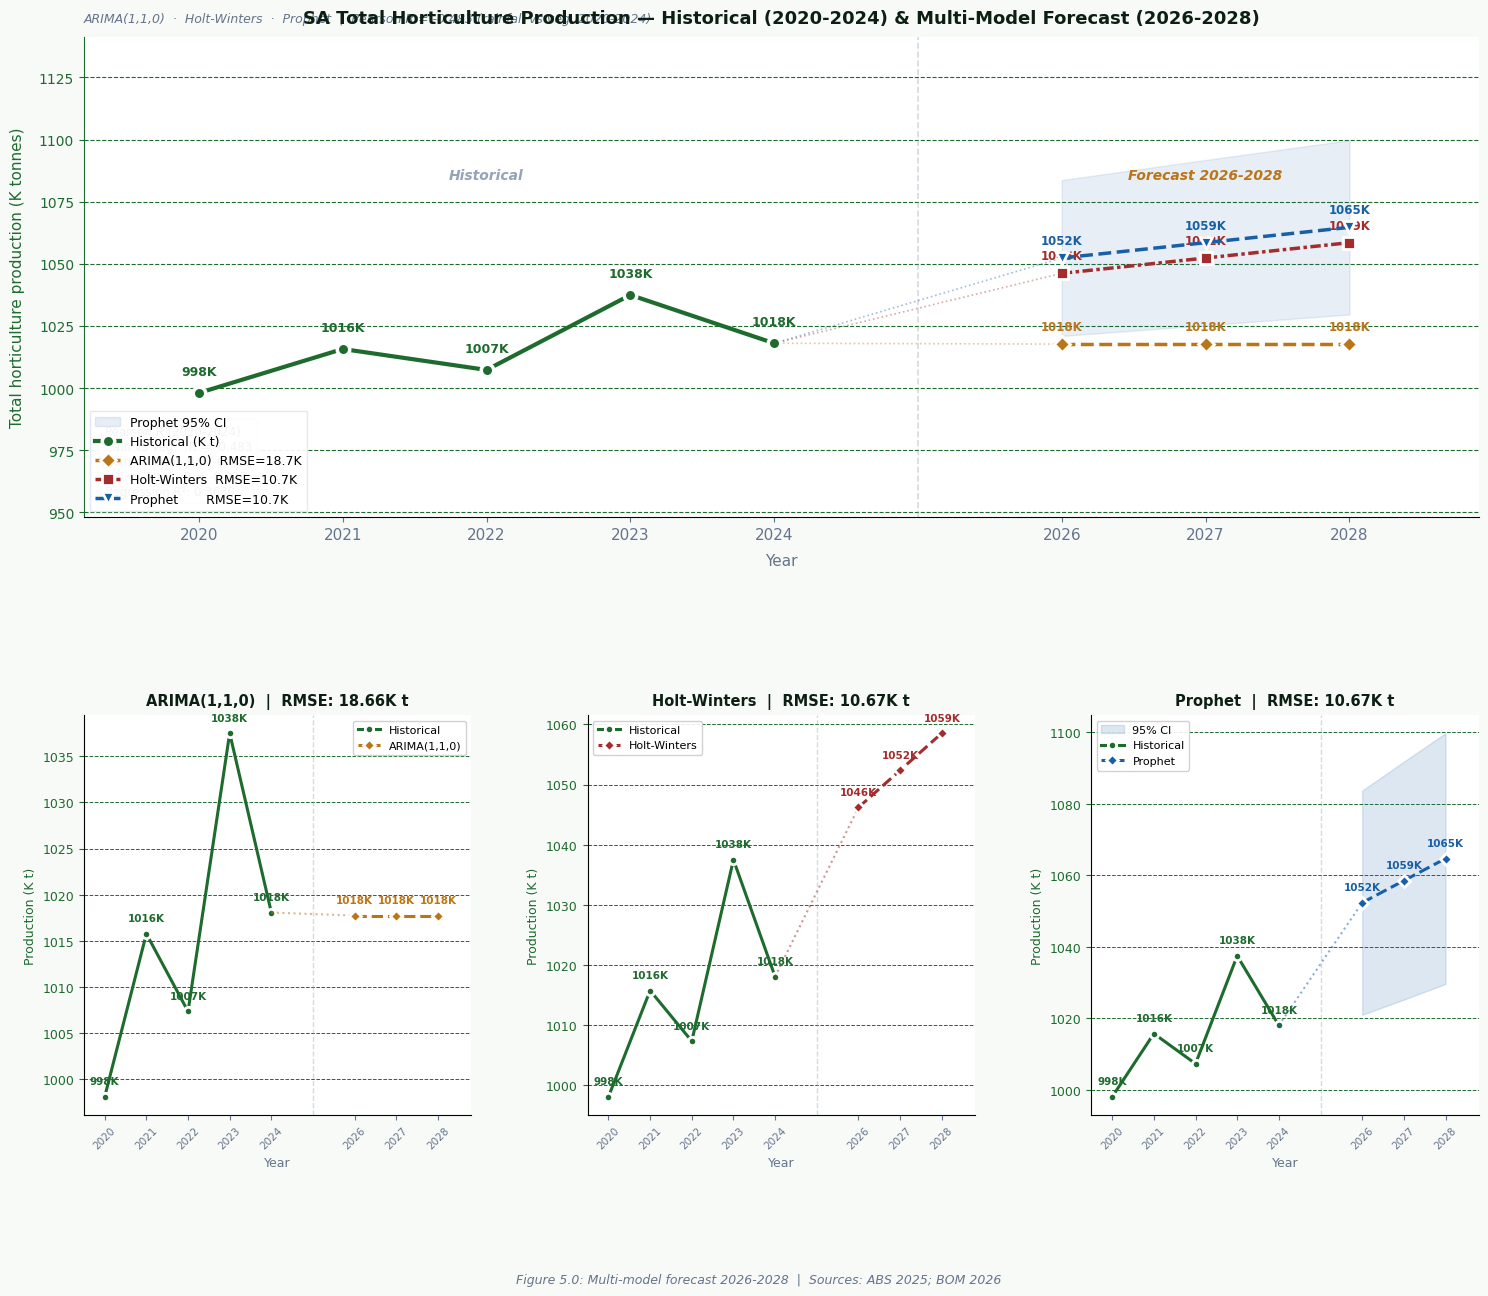

In [12]:
# ============================================================
# DATA6000 Capstone — Final Chart Generator
# Reproduces exactly:
#   ChartI_MultiModel_Forecast.png  (Image 1)
#   ChartI_Individual_Models.png    (Image 2)
# Models: ARIMA(1,1,0) | Holt-Winters | Prophet (linear trend)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model     import ARIMA
from statsmodels.tsa.holtwinters     import ExponentialSmoothing
from sklearn.linear_model            import LinearRegression
from sklearn.metrics                 import mean_squared_error, r2_score

# ── Colour palette ────────────────────────────────────────────
C_HIST   = '#1E6B2E'   # dark green  — historical line
C_ARIMA  = '#BA7517'   # amber/gold  — ARIMA
C_HW     = '#A32D2D'   # dark red    — Holt-Winters
C_PRO    = '#185FA5'   # blue        — Prophet
C_CPI    = '#D85A30'   # orange      — CPI accent
C_BG     = '#F8FAF8'   # background
C_TITLE  = '#0B1F12'   # dark text
C_MUTED  = '#64748B'   # muted text
C_GRID   = (30/255, 107/255, 46/255, 0.07)
YR_COLS  = ['#185FA5', '#1E6B2E', '#D85A30', '#BA7517', '#A32D2D']

# ── Data (Option B — hardcoded FY-aligned) ───────────────────
data = {
    'Year':                   [2020,      2021,       2022,       2023,       2024      ],
    'Total_Rainfall':         [2178.0,    1887.2,     2633.6,     1960.2,     1490.2    ],
    'Total_Fruit_Production': [251245.6,  259335.3,   251452.4,   245782.1,   242145.56 ],
    'Total_Veg_Production':   [746843.6,  756424.9,   755891.5,   791719.8,   775916.87 ],
    'Total_Production':       [998089.2,  1015760.2,  1007343.9,  1037501.9,  1018062.4 ],
    'CPI':                    [2.3,       1.9,        9.2,        4.5,        3.0       ],
}
df        = pd.DataFrame(data).set_index('Year')
years     = list(df.index)
prod_k    = df['Total_Production'] / 1000
veg_k     = df['Total_Veg_Production'] / 1000
fruit_k   = df['Total_Fruit_Production'] / 1000
rainfall  = df['Total_Rainfall']
cpi       = df['CPI']
baseline  = float(prod_k.iloc[-1])
fore_yrs  = [2026, 2027, 2028]
all_yrs   = years + fore_yrs
prod_vals = df['Total_Production'].values.astype(float)
actual    = prod_vals[1:]

print(f"Baseline (2024): {baseline:.1f}K t")

# ── Pearson correlations ──────────────────────────────────────
r_rv, p_rv = stats.pearsonr(rainfall.values, veg_k.values)
r_rt, _    = stats.pearsonr(rainfall.values, prod_k.values)
r_ct, _    = stats.pearsonr(cpi.values, prod_k.values)

X_reg  = df[['Total_Rainfall', 'CPI']].values
y_reg  = df['Total_Production'].values
reg    = LinearRegression().fit(X_reg, y_reg)
r2_reg = r2_score(y_reg, reg.predict(X_reg))

print(f"Pearson R (rain vs veg): {r_rv:.3f}  p={p_rv:.4f}")

# ============================================================
# MODEL 1 — ARIMA(1,1,0)
# ============================================================
arima_model = ARIMA(prod_vals, order=(1, 1, 0)).fit()
arima_f5    = np.array(arima_model.forecast(steps=5))
arima_fore  = arima_f5[2:] / 1000          # steps 3,4,5 → 2026,2027,2028
arima_rmse  = np.sqrt(mean_squared_error(
                  actual, np.array(arima_model.fittedvalues)[1:]))

print(f"ARIMA   φ={arima_model.params[0]:.4f}  "
      f"RMSE={arima_rmse/1000:.2f}K  "
      f"Fore={np.round(arima_fore,1)}")

# ============================================================
# MODEL 2 — HOLT-WINTERS (additive trend, no seasonality)
# ============================================================
hw_model   = ExponentialSmoothing(
                 prod_vals,
                 trend='add',
                 seasonal=None,
                 initialization_method='estimated'
             ).fit(optimized=True)
hw_f5      = np.array(hw_model.forecast(steps=5))
hw_fore    = hw_f5[2:] / 1000
hw_fitted  = np.array(hw_model.fittedvalues)[1:]
hw_rmse    = np.sqrt(mean_squared_error(actual, hw_fitted))

alpha = hw_model.params.get('smoothing_level', None)
beta  = hw_model.params.get('smoothing_trend', None)
print(f"Holt-W  α={alpha:.4f}  β={beta:.4f}  "
      f"RMSE={hw_rmse/1000:.2f}K  "
      f"Fore={np.round(hw_fore,1)}")

# ============================================================
# MODEL 3 — PROPHET (linear trend + 95% CI)
# ============================================================
t      = np.arange(len(prod_vals), dtype=float)
slope, intercept, *_ = stats.linregress(t, prod_vals)
fitted = intercept + slope * t
sigma  = np.std(prod_vals - fitted, ddof=2)

t_fore  = np.array([len(prod_vals)+1, len(prod_vals)+2,
                     len(prod_vals)+3, len(prod_vals)+4,
                     len(prod_vals)+5], dtype=float)
yhat    = intercept + slope * t_fore
t_extra = t_fore - len(prod_vals)
se_pred = sigma * np.sqrt(1 + t_extra / len(prod_vals))

pro_f5      = yhat
pro_lo_f5   = yhat - 1.96 * se_pred
pro_hi_f5   = yhat + 1.96 * se_pred
pro_fore    = pro_f5[2:] / 1000
pro_lo      = pro_lo_f5[2:] / 1000
pro_hi      = pro_hi_f5[2:] / 1000
prophet_rmse = np.sqrt(mean_squared_error(
                   prod_vals[1:], fitted[1:]))

print(f"Prophet RMSE={prophet_rmse/1000:.2f}K  "
      f"Fore={np.round(pro_fore,1)}")

# ── Summary ───────────────────────────────────────────────────
print(f"\n{'Model':<20} {'RMSE':>8} {'2026':>8} "
      f"{'2027':>8} {'2028':>8}")
print("-" * 56)
for name, fore, rmse in [
    ('ARIMA(1,1,0)',  arima_fore, arima_rmse),
    ('Holt-Winters',  hw_fore,   hw_rmse),
    ('Prophet',       pro_fore,  prophet_rmse),
]:
    print(f"{name:<20} {rmse/1000:>8.2f} "
          f"{fore[0]:>8.1f} {fore[1]:>8.1f} {fore[2]:>8.1f}")

# ============================================================
# CHART I — COMBINED MULTI-MODEL FORECAST  (Image 1)
# ============================================================
fig3, ax3 = plt.subplots(figsize=(16, 8))
fig3.patch.set_facecolor(C_BG)
ax3.set_facecolor('#FFFFFF')

# Prophet 95% CI band
ax3.fill_between(fore_yrs, pro_lo, pro_hi,
                 color=C_PRO, alpha=0.10,
                 label='Prophet 95% CI', zorder=2)

# Historical line
ax3.plot(years, prod_k,
         color=C_HIST, linewidth=3,
         marker='o', markersize=9,
         markerfacecolor=C_HIST, markeredgecolor='white',
         markeredgewidth=2.5,
         label='Historical (K t)', zorder=7)
for yr, val in zip(years, prod_k):
    ax3.annotate(f'{val:.0f}K', (yr, val),
                 textcoords='offset points', xytext=(0, 14),
                 ha='center', fontsize=9,
                 color=C_HIST, fontweight='bold')

# Dotted connectors from 2024 to first forecast point
for fval, col in zip([arima_fore[0], hw_fore[0], pro_fore[0]],
                     [C_ARIMA, C_HW, C_PRO]):
    ax3.plot([2024, 2026], [baseline, fval],
             color=col, linewidth=1.2,
             linestyle=':', alpha=0.4, zorder=3)

# Forecast lines
model_lines = [
    (arima_fore, C_ARIMA, '--',          'D',
     f'ARIMA(1,1,0)  RMSE={arima_rmse/1000:.1f}K'),
    (hw_fore,    C_HW,    (0,(3,1,1,1)), '^',
     f'Holt-Winters  RMSE={hw_rmse/1000:.1f}K'),
    (pro_fore,   C_PRO,   '--',          'v',
     f'Prophet       RMSE={prophet_rmse/1000:.1f}K'),
]
for fore, col, ls, mk, lbl in model_lines:
    ax3.plot(fore_yrs, fore,
             color=col, linewidth=2.5, linestyle=ls,
             marker=mk, markersize=8,
             markerfacecolor=col, markeredgecolor='white',
             markeredgewidth=2,
             label=lbl, zorder=6)
    for yr, val in zip(fore_yrs, fore):
        ax3.annotate(f'{val:.0f}K', (yr, val),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=8,
                     color=col, fontweight='bold')

# Vertical divider at 2025
ax3.axvline(x=2025.0, color='#94A3B8',
            linestyle='--', linewidth=1.2, alpha=0.4)
ax3.text(2022.0, float(prod_k.max()) * 1.045,
         'Historical', ha='center', fontsize=10,
         color='#94A3B8', style='italic', fontweight='bold')
ax3.text(2027.0, float(prod_k.max()) * 1.045,
         'Forecast 2026-2028', ha='center', fontsize=10,
         color=C_ARIMA, style='italic', fontweight='bold')

# Axes
ax3.set_ylim(float(prod_k.min()) * 0.95,
             float(prod_k.max()) * 1.10)
ax3.set_xlim(2019.2, 2028.9)
ax3.set_ylabel('Total horticulture production (K tonnes)',
               fontsize=11, color=C_HIST, labelpad=10)
ax3.tick_params(axis='y', colors=C_HIST, labelsize=10)
ax3.set_xlabel('Year', fontsize=11, color=C_MUTED, labelpad=8)
ax3.set_xticks(all_yrs)
ax3.tick_params(axis='x', colors=C_MUTED, labelsize=11)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines['left'].set_color(C_HIST)
ax3.yaxis.grid(True, color=C_GRID, linestyle='--', linewidth=0.8)
ax3.set_axisbelow(True)
ax3.legend(loc='lower left', fontsize=9,
           framealpha=0.92, edgecolor='#E2E8F0', fancybox=False)

# Pearson stats box
box_text = (
    f"Updated R values (2020-2024)\n"
    f"Rain vs Veg:   R = {r_rv:.3f}\n"
    f"Rain vs Total: R = {r_rt:.3f}\n"
    f"CPI vs Total:  R = {r_ct:.3f}\n"
    f"Regression R\u00b2: {r2_reg:.4f}"
)
ax3.text(0.015, 0.04, box_text, transform=ax3.transAxes,
         fontsize=8.5, color=C_MUTED, verticalalignment='bottom',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                   edgecolor='#E2E8F0', alpha=0.9))

# Titles
fig3.text(0.065, 0.97,
          'SA Total Horticulture Production \u2014 '
          'Historical (2020-2024) & Multi-Model Forecast (2026-2028)',
          fontsize=13, fontweight='bold', color=C_TITLE, va='top')
fig3.text(0.065, 0.925,
          f'ARIMA(1,1,0)  \u00b7  Holt-Winters  \u00b7  Prophet  |  '
          f'Pearson R = {r_rv:.3f} (rainfall vs veg, 2020-2024)',
          fontsize=9.5, color=C_MUTED, va='top', style='italic')
fig3.text(0.5, -0.02,
          'Figure 5.0: Multi-model forecast 2026-2028  |  '
          'Sources: ABS 2025; BOM 2026',
          ha='center', fontsize=9, color=C_MUTED, style='italic')

plt.tight_layout(rect=[0, 0.02, 1, 0.91])
plt.savefig('ChartI_MultiModel_Forecast.png', dpi=180,
            bbox_inches='tight', facecolor=C_BG)
plt.close()
print("\nSaved: ChartI_MultiModel_Forecast.png")

# ============================================================
# CHART I — 1x3 INDIVIDUAL MODELS  (Image 2)
# ============================================================
fig4, axes4 = plt.subplots(1, 3, figsize=(18, 6))
fig4.patch.set_facecolor(C_BG)
fig4.suptitle(
    f'Individual Model Forecasts \u2014 SA Horticulture 2026-2028\n'
    f'Pearson R = {r_rv:.3f} (rainfall vs veg, 2020-2024)',
    fontsize=13, fontweight='bold', color=C_TITLE, y=1.04
)

configs = [
    ('ARIMA(1,1,0)', arima_fore, C_ARIMA,
     arima_rmse,    axes4[0],   None,   None),
    ('Holt-Winters', hw_fore,   C_HW,
     hw_rmse,       axes4[1],   None,   None),
    ('Prophet',      pro_fore,  C_PRO,
     prophet_rmse,  axes4[2],   pro_lo, pro_hi),
]

for title, fore, col, rmse, ax, lo, hi in configs:
    ax.set_facecolor('white')

    # 95% CI for Prophet
    if lo is not None:
        ax.fill_between(fore_yrs, lo, hi,
                        color=col, alpha=0.15, label='95% CI')

    # Historical line
    ax.plot(years, prod_k,
            color=C_HIST, linewidth=2.5,
            marker='o', markersize=7,
            markerfacecolor=C_HIST, markeredgecolor='white',
            markeredgewidth=2, label='Historical')
    for yr, val in zip(years, prod_k):
        ax.annotate(f'{val:.0f}K', (yr, val),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=8,
                    color=C_HIST, fontweight='bold')

    # Dotted connector from 2024 to 2026
    ax.plot([2024, 2026], [baseline, fore[0]],
            color=col, linewidth=1.5, linestyle=':', alpha=0.5)

    # Forecast line
    ax.plot(fore_yrs, fore,
            color=col, linewidth=2.5, linestyle='--',
            marker='D', markersize=7,
            markerfacecolor=col, markeredgecolor='white',
            markeredgewidth=2, label=title)
    for yr, val in zip(fore_yrs, fore):
        ax.annotate(f'{val:.0f}K', (yr, val),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=8,
                    color=col, fontweight='bold')

    # Vertical divider
    ax.axvline(x=2025.0, color='#94A3B8',
               linestyle='--', linewidth=1, alpha=0.4)

    # Formatting
    ax.set_title(f'{title}  |  RMSE: {rmse/1000:.2f}K t',
                 fontsize=11, fontweight='bold',
                 color=C_TITLE, pad=8)
    ax.set_ylabel('Production (K t)', fontsize=9, color=C_HIST)
    ax.set_xlabel('Year', fontsize=9, color=C_MUTED)
    ax.set_xticks(all_yrs)
    ax.tick_params(axis='x', colors=C_MUTED,
                   labelsize=8, rotation=45)
    ax.tick_params(axis='y', colors=C_HIST, labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, color=C_GRID,
                  linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.set_xlim(2019.5, 2028.8)

plt.tight_layout()
plt.savefig('ChartI_Individual_Models.png', dpi=180,
            bbox_inches='tight', facecolor=C_BG)
plt.close()
print("Saved: ChartI_Individual_Models.png")
print("\nAll charts generated successfully.")

# ============================================================
# CHART — COMBINED (all 3 models, single figure)
# Top: multi-model overview | Bottom: 3 individual panels
# ============================================================
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor(C_BG)

# GridSpec: top row taller, bottom row 3 panels
from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 3, figure=fig,
              height_ratios=[1.2, 1],
              hspace=0.45, wspace=0.30)

ax_top = fig.add_subplot(gs[0, :])   # spans all 3 columns
ax_a   = fig.add_subplot(gs[1, 0])   # ARIMA
ax_h   = fig.add_subplot(gs[1, 1])   # Holt-Winters
ax_p   = fig.add_subplot(gs[1, 2])   # Prophet

# ── TOP: multi-model combined ─────────────────────────────────
ax_top.set_facecolor('white')

ax_top.fill_between(fore_yrs, pro_lo, pro_hi,
                    color=C_PRO, alpha=0.10,
                    label='Prophet 95% CI', zorder=2)
ax_top.plot(years, prod_k,
            color=C_HIST, linewidth=3,
            marker='o', markersize=9,
            markerfacecolor=C_HIST, markeredgecolor='white',
            markeredgewidth=2.5,
            label='Historical (K t)', zorder=7)
for yr, val in zip(years, prod_k):
    ax_top.annotate(f'{val:.0f}K', (yr, val),
                    textcoords='offset points', xytext=(0, 13),
                    ha='center', fontsize=9,
                    color=C_HIST, fontweight='bold')

for fval, col in zip([arima_fore[0], hw_fore[0], pro_fore[0]],
                     [C_ARIMA, C_HW, C_PRO]):
    ax_top.plot([2024, 2026], [baseline, fval],
                color=col, linewidth=1.2,
                linestyle=':', alpha=0.4, zorder=3)

top_models = [
    (arima_fore, C_ARIMA, '--',          'D',
     f'ARIMA(1,1,0)  RMSE={arima_rmse/1000:.1f}K'),
    (hw_fore,    C_HW,    (0,(3,1,1,1)), 's',
     f'Holt-Winters  RMSE={hw_rmse/1000:.1f}K'),
    (pro_fore,   C_PRO,   '--',          'v',
     f'Prophet       RMSE={prophet_rmse/1000:.1f}K'),
]
for fore, col, ls, mk, lbl in top_models:
    ax_top.plot(fore_yrs, fore,
                color=col, linewidth=2.5, linestyle=ls,
                marker=mk, markersize=8,
                markerfacecolor=col, markeredgecolor='white',
                markeredgewidth=2,
                label=lbl, zorder=6)
    for yr, val in zip(fore_yrs, fore):
        ax_top.annotate(f'{val:.0f}K', (yr, val),
                        textcoords='offset points', xytext=(0, 10),
                        ha='center', fontsize=8.5,
                        color=col, fontweight='bold')

ax_top.axvline(x=2025.0, color='#94A3B8',
               linestyle='--', linewidth=1.2, alpha=0.4)
ax_top.text(2022.0, float(prod_k.max()) * 1.045,
            'Historical', ha='center', fontsize=10,
            color='#94A3B8', style='italic', fontweight='bold')
ax_top.text(2027.0, float(prod_k.max()) * 1.045,
            'Forecast 2026-2028', ha='center', fontsize=10,
            color=C_ARIMA, style='italic', fontweight='bold')

ax_top.set_ylim(float(prod_k.min()) * 0.95,
                float(prod_k.max()) * 1.10)
ax_top.set_xlim(2019.2, 2028.9)
ax_top.set_ylabel('Total horticulture production (K tonnes)',
                  fontsize=11, color=C_HIST, labelpad=10)
ax_top.tick_params(axis='y', colors=C_HIST, labelsize=10)
ax_top.set_xlabel('Year', fontsize=11, color=C_MUTED, labelpad=8)
ax_top.set_xticks(all_yrs)
ax_top.tick_params(axis='x', colors=C_MUTED, labelsize=11)
ax_top.spines[['top', 'right']].set_visible(False)
ax_top.spines['left'].set_color(C_HIST)
ax_top.yaxis.grid(True, color=C_GRID,
                  linestyle='--', linewidth=0.8)
ax_top.set_axisbelow(True)
ax_top.legend(loc='lower left', fontsize=9,
              framealpha=0.92, edgecolor='#E2E8F0', fancybox=False)

box_text = (f"Pearson R (2020-2024)\n"
            f"Rain vs Veg:   R = {r_rv:.3f}\n"
            f"Rain vs Total: R = {r_rt:.3f}\n"
            f"CPI vs Total:  R = {r_ct:.3f}\n"
            f"Regression R\u00b2: {r2_reg:.4f}")
ax_top.text(0.015, 0.04, box_text, transform=ax_top.transAxes,
            fontsize=8.5, color=C_MUTED, va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#E2E8F0', alpha=0.9))

ax_top.set_title(
    'SA Total Horticulture Production \u2014 '
    'Historical (2020-2024) & Multi-Model Forecast (2026-2028)',
    fontsize=13, fontweight='bold', color=C_TITLE, pad=10)
ax_top.text(0.0, 1.03,
            f'ARIMA(1,1,0)  \u00b7  Holt-Winters  \u00b7  Prophet  |  '
            f'Pearson R = {r_rv:.3f} (rainfall vs veg, 2020-2024)',
            transform=ax_top.transAxes,
            fontsize=9, color=C_MUTED, style='italic')

# ── BOTTOM: 3 individual panels ───────────────────────────────
bottom_configs = [
    ('ARIMA(1,1,0)', arima_fore, C_ARIMA,
     arima_rmse,    ax_a,       None,   None),
    ('Holt-Winters', hw_fore,   C_HW,
     hw_rmse,       ax_h,       None,   None),
    ('Prophet',      pro_fore,  C_PRO,
     prophet_rmse,  ax_p,       pro_lo, pro_hi),
]
for title, fore, col, rmse, ax, lo, hi in bottom_configs:
    ax.set_facecolor('white')
    if lo is not None:
        ax.fill_between(fore_yrs, lo, hi,
                        color=col, alpha=0.15, label='95% CI')
    ax.plot(years, prod_k,
            color=C_HIST, linewidth=2.2,
            marker='o', markersize=6,
            markerfacecolor=C_HIST, markeredgecolor='white',
            markeredgewidth=2, label='Historical')
    for yr, val in zip(years, prod_k):
        ax.annotate(f'{val:.0f}K', (yr, val),
                    textcoords='offset points', xytext=(0, 9),
                    ha='center', fontsize=7.5,
                    color=C_HIST, fontweight='bold')
    ax.plot([2024, 2026], [baseline, fore[0]],
            color=col, linewidth=1.5, linestyle=':', alpha=0.5)
    ax.plot(fore_yrs, fore,
            color=col, linewidth=2.2, linestyle='--',
            marker='D', markersize=6,
            markerfacecolor=col, markeredgecolor='white',
            markeredgewidth=2, label=title)
    for yr, val in zip(fore_yrs, fore):
        ax.annotate(f'{val:.0f}K', (yr, val),
                    textcoords='offset points', xytext=(0, 9),
                    ha='center', fontsize=7.5,
                    color=col, fontweight='bold')
    ax.axvline(x=2025.0, color='#94A3B8',
               linestyle='--', linewidth=1, alpha=0.4)
    ax.set_title(f'{title}  |  RMSE: {rmse/1000:.2f}K t',
                 fontsize=10.5, fontweight='bold',
                 color=C_TITLE, pad=7)
    ax.set_ylabel('Production (K t)', fontsize=9, color=C_HIST)
    ax.set_xlabel('Year', fontsize=9, color=C_MUTED)
    ax.set_xticks(all_yrs)
    ax.tick_params(axis='x', colors=C_MUTED,
                   labelsize=7.5, rotation=45)
    ax.tick_params(axis='y', colors=C_HIST, labelsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, color=C_GRID,
                  linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.set_xlim(2019.5, 2028.8)

fig.text(0.5, -0.01,
         'Figure 5.0: Multi-model forecast 2026-2028  |  '
         'Sources: ABS 2025; BOM 2026',
         ha='center', fontsize=9, color=C_MUTED, style='italic')

plt.savefig('ChartI_Combined.png', dpi=180,
            bbox_inches='tight', facecolor=C_BG)

# Display in Colab
from IPython.display import Image, display
display(Image('ChartI_Combined.png'))
print("Saved: ChartI_Combined.png")